### This Notebook demonstrates the process followed in cleaning the filtered news dataset
### Steps followed :
     1. Removing Unwanted columns
     2. Date Formatting and research study period scoping
     3. Handling Missing Values
     4. Handling duplicates
     5. EDA

In [1]:
#Package Import
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import seaborn as sns
import os
%matplotlib inline

In [2]:
#Filtered data from FNSPID Dataset
df_filtered = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\news_data.csv", low_memory=False)
df_filtered.head(3)

,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,70381.0,2023-12-16 05:00:00 UTC,ADSK Quantitative Stock Analysis,ADSK,https://www.nasdaq.com/articles/adsk-quantitat...,NaN,NaN,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate...","Of the 22 guru strategies we follow, ADSK rate...",Below is Validea's guru fundamental report for...
1,70382.0,2023-12-16 02:00:00 UTC,Artificial Intelligence Adding New Depths to 3...,ADSK,https://www.nasdaq.com/articles/artificial-int...,NaN,NaN,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...
2,70383.0,2023-12-12 00:00:00 UTC,Bigbear.Ai (BBAI) Extends Deal With U.S. Army ...,ADSK,https://www.nasdaq.com/articles/bigbear.ai-bba...,NaN,NaN,BigBear.ai BBAI is keeping no stone unturned t...,It also partnered with Autodesk ADSK to develo...,"Click to get this free report Amazon.com, Inc....","Click to get this free report Amazon.com, Inc....",It also partnered with Autodesk ADSK to develo...


In [3]:
#Removing unwanted columns
df_filtered.drop(columns = ['Unnamed: 0','Url','Publisher','Author','Luhn_summary','Lexrank_summary'], inplace=True)
df_filtered.head(3)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary
0,2023-12-16 05:00:00 UTC,ADSK Quantitative Stock Analysis,ADSK,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate..."
1,2023-12-16 02:00:00 UTC,Artificial Intelligence Adding New Depths to 3...,ADSK,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...
2,2023-12-12 00:00:00 UTC,Bigbear.Ai (BBAI) Extends Deal With U.S. Army ...,ADSK,BigBear.ai BBAI is keeping no stone unturned t...,It also partnered with Autodesk ADSK to develo...,"Click to get this free report Amazon.com, Inc...."


In [4]:
#Formatting the date column to strip timezone, and remove the 00:00:00 time component
df_filtered['Date'] = pd.to_datetime(df_filtered['Date']).dt.tz_localize(None).dt.normalize()
df_filtered.head(3)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary
0,2023-12-16,ADSK Quantitative Stock Analysis,ADSK,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate..."
1,2023-12-16,Artificial Intelligence Adding New Depths to 3...,ADSK,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...
2,2023-12-12,Bigbear.Ai (BBAI) Extends Deal With U.S. Army ...,ADSK,BigBear.ai BBAI is keeping no stone unturned t...,It also partnered with Autodesk ADSK to develo...,"Click to get this free report Amazon.com, Inc...."


In [5]:
#Extracting the Year from the Date column
df_filtered['Date'] = pd.to_datetime(df_filtered['Date'], errors='coerce')
df_filtered['Year'] = df_filtered['Date'].dt.year
df_filtered.head(3)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year
0,2023-12-16,ADSK Quantitative Stock Analysis,ADSK,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate...",2023
1,2023-12-16,Artificial Intelligence Adding New Depths to 3...,ADSK,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...,2023
2,2023-12-12,Bigbear.Ai (BBAI) Extends Deal With U.S. Army ...,ADSK,BigBear.ai BBAI is keeping no stone unturned t...,It also partnered with Autodesk ADSK to develo...,"Click to get this free report Amazon.com, Inc....",2023


In [6]:
#Data Period Check
print(df_filtered['Year'].min())
print(df_filtered['Year'].max())

2009
2023


In [7]:
#5-year thesis window - Ensuring only the data in the research period 2019-2023 remains
start_date = pd.Timestamp('2019-01-01')
end_date = pd.Timestamp('2023-12-31')
    
initial_count = len(df_filtered)
df = df_filtered[(df_filtered['Date'] >= start_date) & (df_filtered['Date'] <= end_date)].copy()
    
#Results Reporting
removed = initial_count - len(df)
    
print(f"Pre-2019 Rows Removed: {removed:,}")
print(f"2019-2023 Data Rows: {len(df):,}")

Pre-2019 Rows Removed: 27,052
2019-2023 Data Rows: 65,153


In [8]:
#Checking missing values
df.isna().sum()

Date                   0
Article_title          0
Stock_symbol           0
Article             8923
Lsa_summary         8923
Textrank_summary    8923
Year                   0
dtype: int64

In [9]:
#Summaries are derived from the article hence why the missing values are the same.
#The missing items will be replaced with the Article_title 

df["Article"] = df["Article"].fillna(df["Article_title"])
df["Lsa_summary"] = df["Lsa_summary"].fillna(df["Article_title"])
df["Textrank_summary"] = df["Textrank_summary"].fillna(df["Article_title"])

In [10]:
#Rechecking for missing values
df.isna().sum()

Date                0
Article_title       0
Stock_symbol        0
Article             0
Lsa_summary         0
Textrank_summary    0
Year                0
dtype: int64

In [11]:
#Handling
#This counts how many rows are duplicated across the relevant columns
all_rows = len(df)
duplicate_count = df.duplicated(subset=['Stock_symbol', 'Article']).sum()
print(f"Total duplicate rows: {duplicate_count}")
print(f"Total rows: {all_rows:,}")

Total duplicate rows: 2524
Total rows: 65,153


#### There is no major duplication in the dataset

In [12]:
#Looking at rows that share the same Title but have different Article
duplicates = df[df.duplicated(subset=['Article_title'], keep=False)]

#Sorting so that identical titles are next to each other
duplicate_samples = duplicates.sort_values(by='Article_title')

#Displaying the first 10 rows (5 pairs/groups)
print("Sample of Duplicated Titles and their Articles")
print(duplicate_samples[['Article_title', 'Article']].head(10))

Sample of Duplicated Titles and their Articles
                                           Article_title  \
19088  "Grand Theft Auto" Comes to "FarmVille" as Tak...   
26200  "Grand Theft Auto" Comes to "FarmVille" as Tak...   
56508  "Reduce Excessive Credit Card Fees": Why Visa ...   
16936  "Reduce Excessive Credit Card Fees": Why Visa ...   
85229              #YouTubewakeup: What You Need To Know   
83907              #YouTubewakeup: What You Need To Know   
90615       ' Large-Cap Stocks With High Earnings Yields   
90616       ' Large-Cap Stocks With High Earnings Yields   
87903              ' Spinoff Stocks Worth Your Attention   
87576              ' Spinoff Stocks Worth Your Attention   

                                                 Article  
19088  Shares of Lululemon Athletica (NASDAQ: LULU) f...  
26200  Shares of Lululemon Athletica (NASDAQ: LULU) f...  
56508  Congress is putting major credit card processo...  
16936  Congress is putting major credit card processo...

In [13]:
#Checking if the generic Guru Report titles actually changes article text
#Using WMT - Wallmart
guru_reports = df[df['Article_title'] == "Guru Fundamental Report for WMT"]

#Counting unique text entries for these 55 reports
unique_guru_content = guru_reports['Article'].nunique()

print(f"Total Guru Reports: {len(guru_reports)}")
print(f"Unique Content Versions: {unique_guru_content}")

Total Guru Reports: 55
Unique Content Versions: 16


In [14]:
#Widening the search for generic titles vs unique content
#Grouping by Title and counting how many times they appear
#Then, for each title, we review how many unique Article texts it has

eda_report = df.groupby('Article_title').agg({
    'Article': ['count', 'nunique']
})

#Flattening the columns for easier reading
eda_report.columns = ['Total_Occurrences', 'Unique_Content_Versions']
eda_report = eda_report.sort_values(by='Total_Occurrences', ascending=False)

print(eda_report)

                                                    Total_Occurrences  \
Article_title                                                           
Guru Fundamental Report for WMT                                    55   
Guru Fundamental Report for GS                                     48   
Guru Fundamental Report for PYPL - Martin Zweig                    48   
Guru Fundamental Report for XOM - Peter Lynch                      44   
Guru Fundamental Report for INTC                                   43   
...                                                               ...   
Eleven U.S. senators urge internet providers to...                  1   
Eli Lilly plans new 2 bln euro German plant -so...                  1   
Elite Wealth Management, LLC Buys Intel Corp, H...                  1   
Elite Wealth Management, LLC Buys ProShares Ult...                  1   
“Yes in My Backyard”: How the Shift from China-...                  1   

                                                  

In [15]:
#Dropping Duplicates
df_nondup = df.drop_duplicates(subset=['Stock_symbol', 'Article'], keep='first').copy()

#Total differences
print(f"Total rows before: {len(df):,}")
print(f"Total rows after: {len(df_nondup):,}")

Total rows before: 65,153
Total rows after: 62,629


In [16]:
print(f"Total Rows Removed as Redundant: {len(df) - len(df_nondup)}")

Total Rows Removed as Redundant: 2524


In [17]:
df_nondup = df_nondup.reset_index(drop=True)

In [18]:
#Re-running this code to check if the generic rows have been dropped
#Using WMT - Wallmart
guru_reports =  df_nondup[df_nondup['Article_title'] == "Guru Fundamental Report for WMT"]

#Counting unique text entries for these 55 reports
unique_guru_content = guru_reports['Article'].nunique()

print(f"Total Guru Reports: {len(guru_reports)}")
print(f"Unique Content Versions: {unique_guru_content}")

Total Guru Reports: 12
Unique Content Versions: 12


From above results, it is clear that only titles that have unique articles have beeen retained from the generic news.

In [19]:
#From a random article view I had run, I noticed DE which represents Deere & Co might have been picked while filtering for delta airlines
#We shall be checking the number of rows referencing DE

#Count by Ticker
deere_count = len(df[df['Stock_symbol'] == 'DE'])

#Count by String Match
# 'na=False' ensures we don't crash on empty rows
deere_string = df['Article'].str.contains('Deere', case=False, na=False)
deere_string_count = deere_string.sum()

print(f"Rows mentioning 'Deere' in text: {deere_string_count}")

Rows mentioning 'Deere' in text: 1927


In [20]:
#Counting Deere occurences where the ticker symbol is DAL
de_in_dal = (df_nondup['Article'].str.contains('Deere', case=False, na=False)) & (df_nondup['Stock_symbol'] == 'DAL')
de_count = de_in_dal.sum()
print(f"Number of rows where Deere is incorrectly tagged to DAL: {de_count}")

Number of rows where Deere is incorrectly tagged to DAL: 1726


The above proves that some news covering Deere & Co.(NYSE: DE) were collected while filtering for Delta Airlines

In [21]:
#Displaying a few articles for confirmation
print(df_nondup[de_in_dal][['Stock_symbol', 'Article']].head())

      Stock_symbol                                            Article
9975           DAL  By Lisa Baertlein and Bianca Flowers\nJune 23 ...
10413          DAL  T\nhe year 2022 has been a difficult one for i...
10486          DAL  Deere & Company DE has been gaining from solid...
10487          DAL  Investors often turn to recommendations made b...
10488          DAL  Below is Validea's guru fundamental report for...


In [22]:
#This shows that the news article is related to Deere (DE) and 
df_nondup.iloc[10487]['Article']

'Investors often turn to recommendations made by Wall Street analysts before making a Buy, Sell, or Hold decision about a stock. While media reports about rating changes by these brokerage-firm employed (or sell-side) analysts often affect a stock\'s price, do they really matter?\nBefore we discuss the reliability of brokerage recommendations and how to use them to your advantage, let\'s see what these Wall Street heavyweights think about Deere (DE).\nDeere currently has an average brokerage recommendation (ABR) of 1.80, on a scale of 1 to 5 (Strong Buy to Strong Sell), calculated based on the actual recommendations (Buy, Hold, Sell, etc.) made by 20 brokerage firms. An ABR of 1.80 approximates between Strong Buy and Buy.\nOf the 20 recommendations that derive the current ABR, 12 are Strong Buy, representing 60% of all recommendations.\nBrokerage Recommendation Trends for DE\n\n\nCheck price target & stock forecast for Deere here>>>\n\nThe ABR suggests buying Deere, but making an inves

In [23]:
#tilde operator (~) will retain everything except the contaminated rows.
#New cleaned dataframe created
df_cleaned = df_nondup[~de_in_dal].copy()

print(f"Non Duplicate Row Count: {len(df_nondup):,}")
print(f"New Row Count: {len(df_cleaned):,}")
print(f"Removed count: {len(df_nondup) - len(df_cleaned)}")

Non Duplicate Row Count: 62,629
New Row Count: 60,903
Removed count: 1726


In [24]:
#Number of articles per Stock_symbol - 2019 -2023 Dataset
stock_counts = df['Stock_symbol'].value_counts()
print("Top Tickers by Volume")
print(stock_counts)

Top Tickers by Volume
GOOGL    11339
INTC      9007
WMT       8570
XOM       7245
GS        6207
PYPL      4710
DAL       3838
CMCSA     3323
BX        2878
FOX       2038
BKR       1978
ADSK      1377
APA       1190
HPE        945
APTV       508
Name: Stock_symbol, dtype: int64


In [25]:
#Number of articles per Stock_symbol - Cleaned dataset A
stocks = df_cleaned['Stock_symbol'].value_counts()
print("Top Tickers by Volume")
print(stocks)

Top Tickers by Volume
GOOGL    10372
INTC      8826
WMT       8414
XOM       7046
GS        6051
PYPL      4603
CMCSA     3239
BX        2801
DAL       1987
BKR       1962
FOX       1649
ADSK      1334
APA       1180
HPE        935
APTV       504
Name: Stock_symbol, dtype: int64


In [26]:
#Adding an article length column to the cleaned dataset
df_cleaned['Article_Length'] = df_cleaned['Article'].apply(lambda x:len(x))
df_cleaned.head(3)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length
0,2023-12-16,ADSK Quantitative Stock Analysis,ADSK,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate...",2023,2968
1,2023-12-16,Artificial Intelligence Adding New Depths to 3...,ADSK,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...,2023,9366
2,2023-12-12,Bigbear.Ai (BBAI) Extends Deal With U.S. Army ...,ADSK,BigBear.ai BBAI is keeping no stone unturned t...,It also partnered with Autodesk ADSK to develo...,"Click to get this free report Amazon.com, Inc....",2023,4136


In [27]:
#Exporting cleaned dataset that will be the baseline dataset A.
output_dir = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\News'
news_file_path = os.path.join(output_dir, 'News_Dataset A.csv')
df_cleaned.to_csv(news_file_path, index=False)
print(f"Successfully saved!")

Successfully saved!


In [28]:
#Ensuring the cleaned dataset does not contain transcripts
# Headline pattern
headline_pattern = r'(?:Earnings\sCall\sTranscript|Conference\sCall\sTranscript|Edited\sTranscript|Final\sTranscript)'

# Body Structural markers
body_pattern = r'(?:^Operator:|^Safe\sHarbor\sStatement|^Ready\sfor\sQuestions)'

#Logic
mask_headline = df_cleaned['Article_title'].str.contains(headline_pattern, case=False, na=False, regex=True)
mask_body = df_cleaned['Article'].str.contains(body_pattern, case=False, na=False, regex=True)

#Combining the search pattern
mask_transcripts = (mask_headline | mask_body).astype(bool)

#Datasets
df_transcripts = df_cleaned[mask_transcripts].copy()
df_news = df_cleaned[~mask_transcripts].copy()

total_n = len(df_cleaned)
news_n = len(df_news)
trans_n = len(df_transcripts)

print(f"Total Input Rows: {total_n:,}")
print(f"News Articles (B): {news_n:,}")
print(f"Transcripts Identified: {trans_n:,}")

Total Input Rows: 60,903
News Articles (B): 60,719
Transcripts Identified: 184


In [29]:
df_transcripts = df_transcripts.reset_index(drop=True)
df_transcripts.head(3)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length
0,2023-11-22,Autodesk (ADSK) Q3 2024 Earnings Call Transcript,ADSK,Image source: The Motley Fool.\nAutodesk (NASD...,Autodesk (NASDAQ: ADSK) Q3 2024 Earnings Call ...,Operator [Operator signoff] Duration: 0 minute...,2023,59073
1,2023-08-23,Autodesk (ADSK) Q2 2024 Earnings Call Transcript,ADSK,Image source: The Motley Fool.\nAutodesk (NASD...,Autodesk (NASDAQ: ADSK) Q2 2024 Earnings Call ...,Operator [Operator signoff] Duration: 0 minute...,2023,57871
2,2023-05-25,Autodesk (ADSK) Q1 2024 Earnings Call Transcript,ADSK,Image source: The Motley Fool.\nAutodesk (NASD...,Autodesk (NASDAQ: ADSK) Q1 2024 Earnings Call ...,Operator [Operator signoff] Duration: 0 minute...,2023,60215


In [30]:
#Title verification
df_transcripts.iloc[182]['Article_title']

'Intel Corp (INTC) CEO Robert Swan on Q1 2019 Results - Earnings Call Transcript'

In [31]:
#Article Verifcation
df_transcripts.iloc[0]['Article']

"Image source: The Motley Fool.\nAutodesk (NASDAQ: ADSK)\nQ3 2024 Earnings Call\nNov 21, 2023, 5:00 p.m. ET\nContents:\nPrepared Remarks\nQuestions and Answers\nCall Participants\nPrepared Remarks:\n\nOperator\nThank you for standing by, and welcome to Autodesk's third quarter fiscal year 2024 earnings conference call. At this time, all participants are in a listen-only mode. After the speaker presentation, there will be a question-and-answer session. [Operator instructions] I would now like to hand the call over to VP of investor relations, Simon Mays-Smith.\nPlease go ahead.\nSimon Mays-Smith -- Vice President, Investor Relations\nThanks, operator, and good afternoon. Thank you for joining our conference call to discuss the third quarter results of Autodesk's fiscal '24. On the line with me are Andrew Anagnost, our CEO; and Debbie Clifford, our CFO. Today's conference call is being broadcast live via webcast.\nIn addition, a replay of the call will be available at autodesk.com/invest

In [32]:
df_news = df_news.reset_index(drop=True)

To create an optimum Dataset B, the cleaned data with the transcripts removed will be filtered for relevant news only. The criteria used ensures the stock symbol is either mentioned on the news article title or the symbol is mentioned more than twice in the aricle body. The goal of having two datasets is to compare the accuracy of Models while using both Dataset A and B.

In [33]:
#Defining the Master Alias Map
alias_map = {
    "INTC": r'Intel|Pat Gelsinger|Intel Corporation|INTC',
    "WMT": r'Walmart|wmt',
    "GOOGL": r'Google|Alphabet Inc.|Sundar Pichai|YouTube|DeepMind|AdSense|Gemini',
    "GS": r'Goldman Sachs|David Solomon|Investment Banking',
    "DAL": r'Delta|Ed Bastian|Delta Air Lines, Inc|Airlines|Aviation',
    "CMCSA": r'Comcast|Xfinity|NBCUniversal|Comcast Corporation|Sky Group',
    "BX": r'Blackstone|Blackstone Inc.|Private Equity|Investment',
    "ADSK": r'Autodesk|Autodesk, Inc.|Andrew Anagnost',
    "HPE": r'Hewlett Packard Enterprise|HPE|Antonio Neri',
    "PYPL": r'PayPal|Venmo|Alex Chriss|PayPal Holdings, Inc.',
    "APTV": r'Aptiv|Kevin Clark|Autonomous Driving|Aptiv PLC',
    "FOX": r'Fox Corp|Lachlan Murdoch|Fox News|Fox Sports|Fox',
    "XOM": r'Exxon|Mobil|Darren Woods|Permian Basin|ExxonMobil',
    "BKR": r'Baker Hughes|Lorenzo Simonelli|Oilfield Services',
    "APA": r'APA Corp|Apache Corp|John Christmann|Apache Corporation'
}

def apply_filter(df, mapping):
    initial_len = len(df)
    
    # Pre-calculate counts to avoid slow loops
    keep_mask = []
    
    for idx, row in df.iterrows():
        ticker = row['Stock_symbol']
        title = str(row['Article_title'])
        article = str(row['Article'])
        pattern = mapping.get(ticker, "")
        
        if not pattern:
            keep_mask.append(False)
            continue
            
        #Title Relevance
        #If the company is in the title, it is retained regardless of frequency.
        in_title = bool(re.search(pattern, title, re.IGNORECASE))
        
        #Frequency - Finding all occurrences in the body text.
        mentions = re.findall(pattern, article, re.IGNORECASE)
        mention_count = len(mentions)
        
        #Retained if In Title OR Mentions >= 2
        if in_title or mention_count >= 2:
            keep_mask.append(True)
        else:
            keep_mask.append(False)
            
    df_filter = df[keep_mask].copy()
    print(f"✅ Filter Complete. Removed {initial_len - len(df_filter):,} irrelevant rows.")
    return df_filter

# EXECUTION for Dataset B
df_final = apply_filter(df_news, alias_map)

✅ Filter Complete. Removed 17,995 irrelevant rows.


In [34]:
#Number of articles per Stock_symbol - Final dataset (B)
tickers = df_final['Stock_symbol'].value_counts()
print("Top Tickers by Volume")
print(tickers)

Top Tickers by Volume
WMT      7356
INTC     6877
XOM      6262
GOOGL    5085
PYPL     3577
GS       3092
CMCSA    2170
BX       2037
DAL      1376
FOX      1209
BKR      1081
ADSK      858
HPE       770
APA       568
APTV      406
Name: Stock_symbol, dtype: int64


In [35]:
#Dataframe to store the Dropped rows
dropped_rows = df_news[~df_news.index.isin(df_final.index)]
print(dropped_rows['Article_title'].head(10))

6     Noteworthy Wednesday Option Activity: COF, BX,...
11    US STOCKS-Wall St eyes higher open as yields s...
12    Technology Sector Update for 11/22/2023: DLO, ...
16    After-Hours Earnings Report for November 21, 2...
18    Option Volatility And Earnings Report For Nove...
24    Noteworthy Thursday Option Activity: TEAM, ADS...
25    Notable ETF Outflow Detected - IGV, CDNS, ADSK...
30         How to (Actually) Get Rich With AI Investing
35     Notable Tuesday Option Activity: ADSK, FLR, AFRM
47    Stocks Tumble on a Sell-Off in Mega-Cap Tech S...
Name: Article_title, dtype: object


In [36]:
dropped_rows = dropped_rows.reset_index(drop=True)

In [37]:
print(dropped_rows['Article_title'].tail(10))

17985                      Investing Beyond Flash And DRAM
17986    Here's What to Expect from Micron (MU) Stock i...
17987    AMD: My Top Tech Pick For 2018 Was The S&P 500...
17988    Microsoft (MSFT) Debuts Surface Go in India vi...
17989    Stock Market Futures Dive; Dow Jones Chipmaker...
17990    Dow Jones Futures: 'Let's Make A Deal' Trump F...
17991    Williams to Build 1-40 MW Solar Stations Acros...
17992    Zoom Stock Rises Then Falls After Blockbuster ...
17993    This Trio of Graham-Style Stocks Appears to Be...
17994    Is a Beat in the Cards for ProPetro (PUMP) in ...
Name: Article_title, dtype: object


In [38]:
#Adding Relevance Score to the final filtered dataset for news weight

def calculate_relevance_score(row, mapping):
    ticker = row['Stock_symbol']
    pattern = mapping.get(ticker, "")
    title = str(row['Article_title'])
    article = str(row['Article'])
    
    if not pattern: return 0
    
    #Title Weight
    title_score = 5 if re.search(pattern, title, re.IGNORECASE) else 0
    
    #Frequency
    mentions = re.findall(pattern, article, re.IGNORECASE)
    density_score = len(mentions) * 2
    
    #Position Weight-Checking if mentioned in the first 200 characters
    lead_score = 3 if re.search(pattern, article[:200], re.IGNORECASE) else 0
    
    return title_score + density_score + lead_score

#Applying to the final dataset
df_final['relevance_score'] = df_final.apply(
    lambda row: calculate_relevance_score(row, alias_map), axis=1
)

In [39]:
#Calclating article length
df_final['Article_Length'] = df_final['Article'].apply(lambda x:len(x))

In [40]:
#Adding News Market Cycles -Trial
#Loading the source data again since the date/timestamps in the other datasets have been normalized.
df_filtered2 = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\news_data.csv", low_memory=False)

In [41]:
#Market Cycle Function
def assign_market_phase(df, timestamp_col='Date'):
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    
    #Extracting the hour and minute as a decimal, for example 9:30 becomes 9.5
    df['decimal_hour'] = df[timestamp_col].dt.hour + df[timestamp_col].dt.minute / 60
    
    def get_phase(hour):
        if 4 <= hour < 9.5:   return 'Pre-Market'
        if 9.5 <= hour < 16:  return 'Market Hours'
        if 16 <= hour < 20:   return 'After-Hours'
        return 'Overnight'

    df['market_phase'] = df['decimal_hour'].apply(get_phase)

    #Summary
    print("Market Phase Distribution")
    print(df['market_phase'].value_counts(normalize=True).map('{:.2%}'.format))
    return df

df_filtered2 = assign_market_phase(df_filtered2)

Market Phase Distribution
Overnight       99.83%
Pre-Market       0.12%
Market Hours     0.04%
After-Hours      0.01%
Name: market_phase, dtype: object


Will ignore the market cyles, because most of the data fall under overnight meaning most entries lack correct timestamps.

In [42]:
#Comparative Descriptive Statistics for the Experimental datasets.
def generate_summary(df_a, df_b, text_col='Article'):
    
    #Calculating Duplicate Rate
    def get_dup_rate(df):
        total = len(df)
        if total == 0: return 0
        unique = df[text_col].nunique()
        duplicates = total - unique
        return (duplicates / total) * 100
        
    metrics = {
        'Total Rows (N)': [len(df_a), len(df_b)],
        'Unique Articles': [df_a[text_col].nunique(), df_b[text_col].nunique()],
        'Duplicate Rate (%)': [get_dup_rate(df_a), get_dup_rate(df_b)],
        'Mean Article Length': [df_a['Article_Length'].mean(), df_b['Article_Length'].mean()],
        'Avg Relevance Score': [np.nan, df_b['relevance_score'].mean()] #No relevance score for dataset A
    }
    
    #DataFrame to hold the metrics
    summary_df = pd.DataFrame(metrics, index=['Dataset A (Cleaned)', 'Dataset B (Filtered)']).T
    
    #Calculate(%) change - Delta
    #Formula: ((B - A) / A) * 100
    summary_df['Delta (%)'] = ((summary_df.iloc[:, 1] - summary_df.iloc[:, 0]) / summary_df.iloc[:, 0]) * 100
    
    # Clean up formatting for the table
    summary_df.iloc[0:2] = summary_df.iloc[0:2].round(0).astype(int) 
    summary_df.iloc[2:] = summary_df.iloc[2:].round(2)               
    
    return summary_df

execution_table = generate_summary(df_cleaned, df_final)
print(execution_table)

                     Dataset A (Cleaned)  Dataset B (Filtered)  Delta (%)
Total Rows (N)                  60903.00              42724.00     -30.00
Unique Articles                 58434.00              41761.00     -29.00
Duplicate Rate (%)                  4.05                  2.25     -44.40
Mean Article Length              4356.37               4615.77       5.95
Avg Relevance Score                  NaN                 15.94        NaN


Dataset A was not scored because it contained "Noise" (duplicates and generic summaries) that the scoring algorithm was specifically designed to identify and remove.
A negative Delta in the Duplicate Rate shows that the cleaning pipeline successfully purified the corpus.

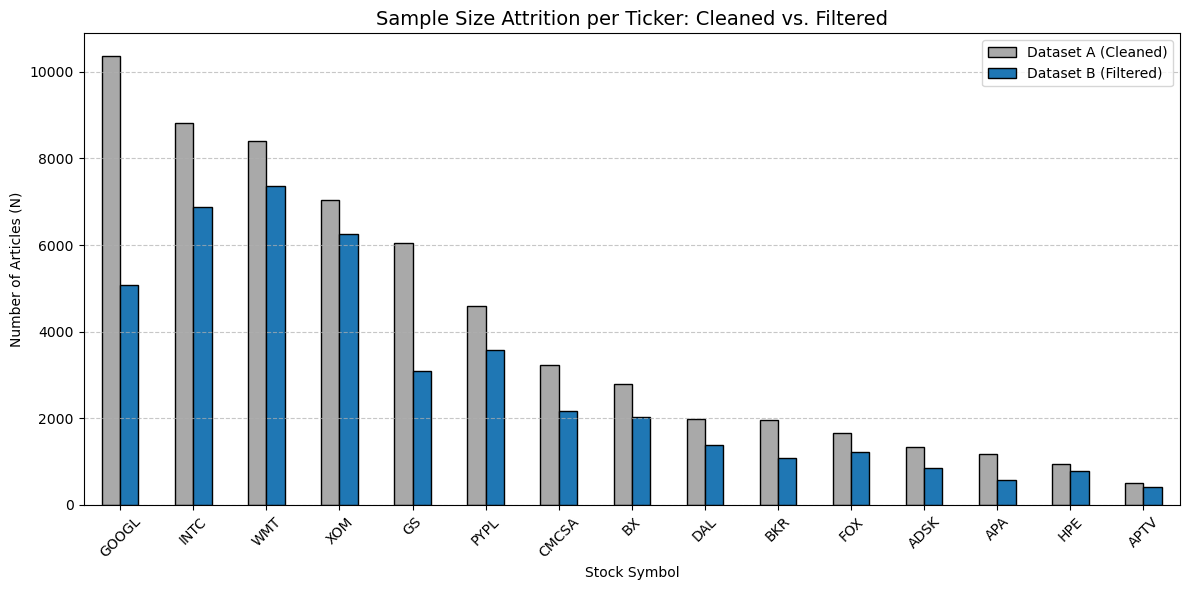

In [43]:
#The Comparative Ticker Distribution (Grouped Bar Chart)
def plot_ticker_comparison(df_a, df_b,ticker_col_a='Stock_symbol', ticker_col_b='Stock_symbol'):
    # Count rows per ticker
    counts_a = df_a['Stock_symbol'].value_counts().sort_index()
    counts_b = df_b['Stock_symbol'].value_counts().sort_index()
    
    comparison_df = pd.DataFrame({'Dataset A (Cleaned)': counts_a, 'Dataset B (Filtered)': counts_b}
                                ).fillna(0).sort_values(by='Dataset A (Cleaned)', ascending=False)
    
    comparison_df.plot(kind='bar', figsize=(12, 6), color=['#A9A9A9', '#1f77b4'], edgecolor='black')
    plt.title('Sample Size Attrition per Ticker: Cleaned vs. Filtered', fontsize=14)
    plt.ylabel('Number of Articles (N)')
    plt.xlabel('Stock Symbol')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('ticker_attrition_comparison.png', dpi=300)
    plt.show()
       
plot_ticker_comparison(df_cleaned, df_final)

In [44]:
#Relevance Summary table
def relevance_summary(df):
    # Bins: 2-4 (Low), 5-9 (Medium), 10+ (High)
    bins = [2, 5, 10, np.inf]
    labels = ['Low Impact (2-4)', 'Medium Impact (5-9)', 'High Impact (10+)']
    
    # 2. Categorize the scores
    df['Relevance_Tier'] = pd.cut(df['relevance_score'], bins=bins, labels=labels, right=False)
    
    # 3. Calculate Distribution
    tier_counts = df['Relevance_Tier'].value_counts().reindex(labels).reset_index()
    tier_counts.columns = ['Salience_Tier', 'Article_Count']
    tier_counts['Percentage (%)'] = (tier_counts['Article_Count'] / len(df)) * 100
    
    return tier_counts


tier_summary = relevance_summary(df_final)

print("Relevance Distribution")
print(tier_summary.to_string(index=False))

Relevance Distribution
      Salience_Tier  Article_Count  Percentage (%)
   Low Impact (2-4)           8383       19.621290
Medium Impact (5-9)           7961       18.633555
  High Impact (10+)          26380       61.745155


A substantial portion of the dataset B consists of high impact news providing adequate context required for Transformer-based models like FinBERT. The Medium Impact tier represents articles where the stock is discussed significantly but perhaps not as the sole focus. These metrics proves Dataset B is not just smaller, it is mathematically tiered by relevance, allowing for a more nuanced understanding of how model performance correlates with news quality.

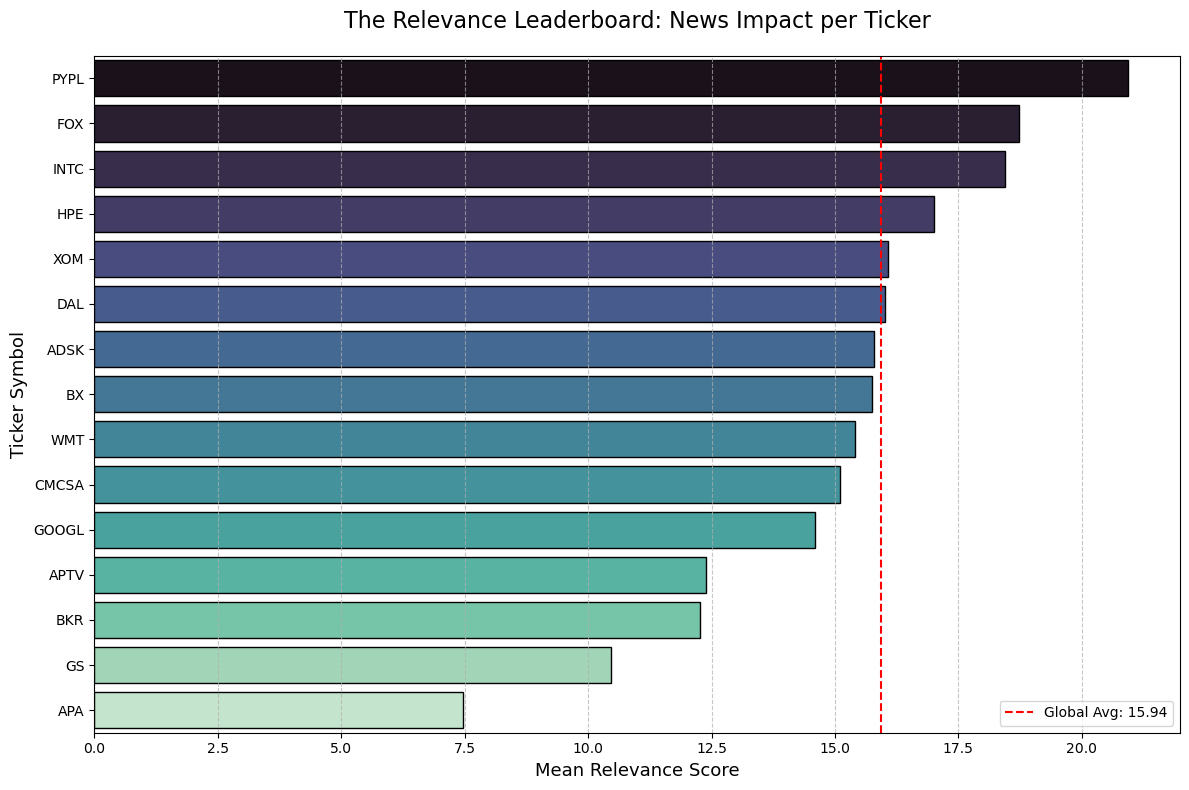

In [45]:
#The Relevance Leaderboard (Mean Bar Chart)
#We group by Ticker and calculate the mean, then sort for the Leaderboard effect
leaderboard = df_final.groupby('Stock_symbol')['relevance_score'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))

sns.barplot(
    x='relevance_score', 
    y='Stock_symbol', 
    data=leaderboard, 
    palette='mako', 
    edgecolor='black'
)

#Formatting
plt.title('The Relevance Leaderboard: News Impact per Ticker', fontsize=16, pad=20)
plt.xlabel('Mean Relevance Score', fontsize=13)
plt.ylabel('Ticker Symbol', fontsize=13)

#Adding a vertical line  for the global average
avg_rel = df_final['relevance_score'].mean()
plt.axvline(avg_rel, color='red', linestyle='--', label=f'Global Avg: {avg_rel:.2f}')

#Display
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('relevance_leaderboard.png', dpi=300)
plt.show()

Tickers such as [PYPL,FOX,HPE] exhibit higher narrative density, suggesting they are primary subjects of financial discourse. Conversely, tickers appearing at the lower end of the spectrum indicate a news cycle characterized by more frequent but less descriptive Ancillary Mentions. This variance in signal density is a key variable in the comparative performance of the Traditional ML and Transformer-based (LLM) models.

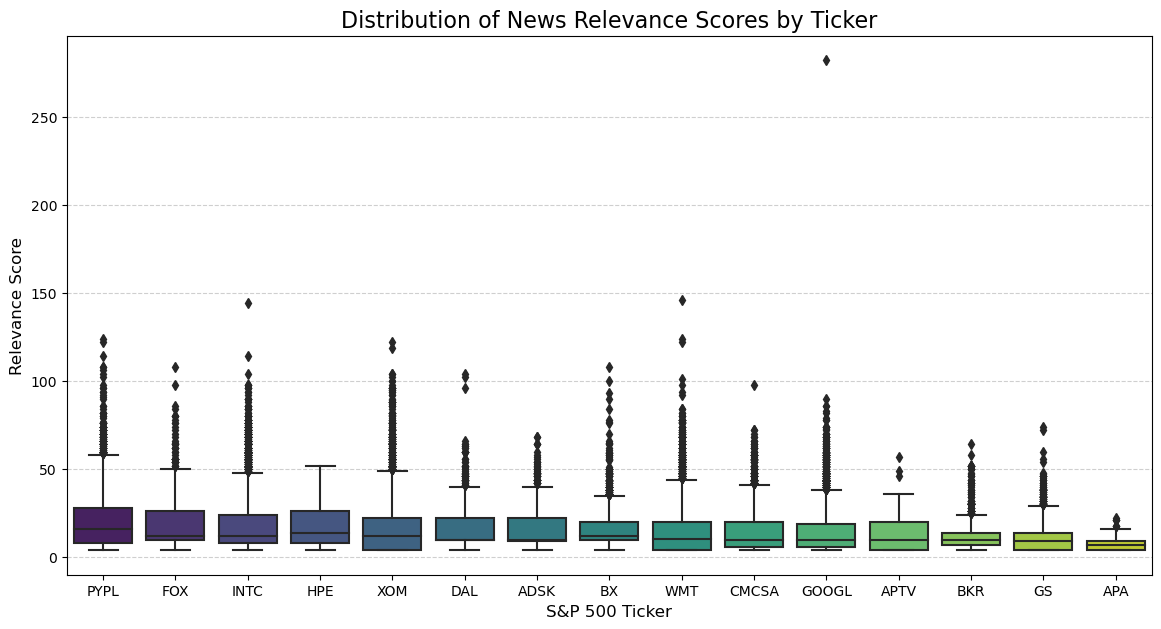

In [46]:
#The Consistency Box Plot (Relevance Distribution)
order = df_final.groupby("Stock_symbol")["relevance_score"].mean().sort_values(ascending=False).index

plt.figure(figsize=(14, 7))
sns.boxplot(x='Stock_symbol', y='relevance_score', data=df_final, order=order, palette="viridis")

plt.title('Distribution of News Relevance Scores by Ticker', fontsize=16)
plt.ylabel('Relevance Score', fontsize=12)
plt.xlabel('S&P 500 Ticker', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('ticker_relevance_distribution.png', dpi=300)
plt.show()

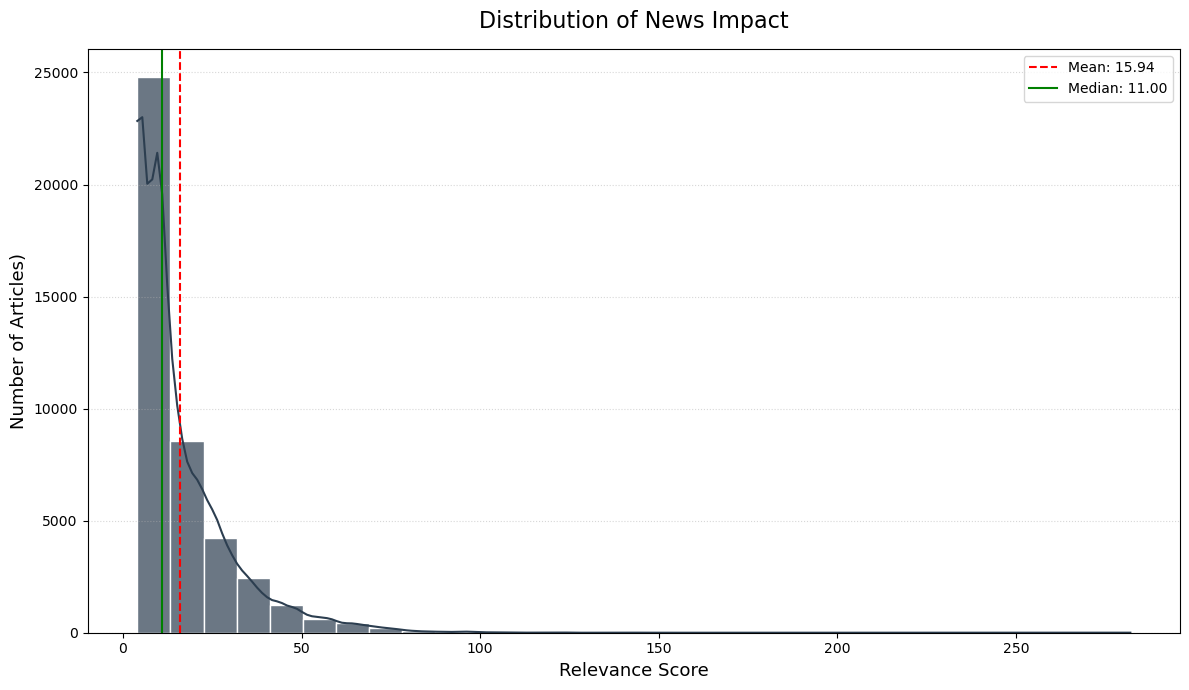

In [47]:
#Histogram of the relevance scores across the whole dataset.

plt.figure(figsize=(12, 7))

#KDE helps visualize the probability density
sns.histplot(
    df_final['relevance_score'], 
    bins=30, 
    kde=True, 
    color='#2c3e50', 
    edgecolor='white',
    alpha=0.7
)

#Statistical Markers
mu = df_final['relevance_score'].mean()
median = df_final['relevance_score'].median()

plt.axvline(mu, color='red', linestyle='--', label=f'Mean: {mu:.2f}')
plt.axvline(median, color='green', linestyle='-', label=f'Median: {median:.2f}')

#Formatting
plt.title('Distribution of News Impact', fontsize=16, pad=15)
plt.xlabel('Relevance Score', fontsize=13)
plt.ylabel('Number of Articles)', fontsize=13)

plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('relevance_histogram.png', dpi=300)
plt.show()

Audit Summary
Date Range: 2019-01-02 to 2023-12-16
Total Unique Days with News: 1802
No major global blackouts found (>3 days).


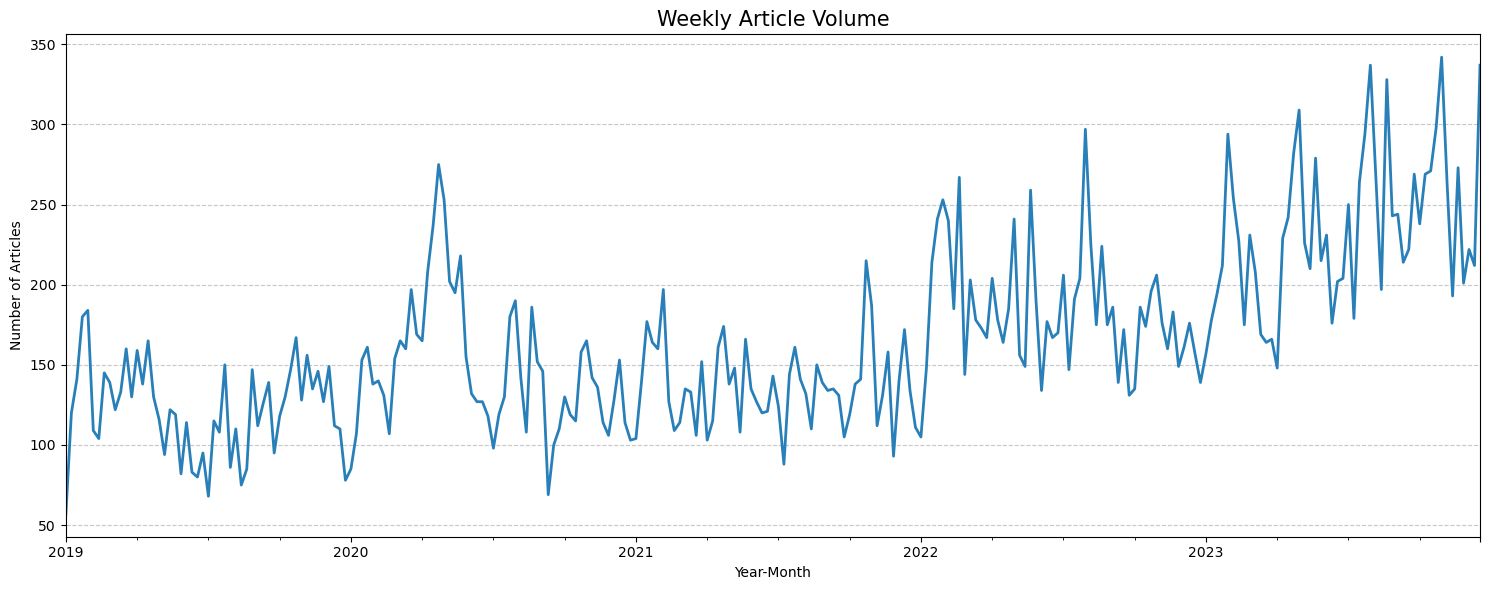

In [48]:
#Data Continuity - Cheching for missing news

def audit_continuity(df):
    
    df['Date'] = pd.to_datetime(df['Date'])
    
    #Sorting the Data - Critical for Time-Series Analysis
    df = df.sort_values(by=['Date', 'Stock_symbol']).reset_index(drop=True)
    
    #Checking for Gaps
    unique_dates = pd.Series(df['Date'].dt.date.unique()).sort_values()
    date_gaps = unique_dates.diff().dt.days
    
    print("Audit Summary")
    print(f"Date Range: {unique_dates.min()} to {unique_dates.max()}")
    print(f"Total Unique Days with News: {len(unique_dates)}")
    
    #Identifying gaps larger than 3 days 
    significant_gaps = date_gaps[date_gaps > 3]
    if not significant_gaps.empty:
        print(f"\nFound {len(significant_gaps)} significant blackout periods (>3 days).")
        print("Top 5 largest gaps (in days):")
        print(significant_gaps.nlargest(5))
    else:
        print("No major global blackouts found (>3 days).")

    #Visual of Data Density
    plt.figure(figsize=(15, 6))
    df.set_index('Date').resample('W').size().plot(color='#2980b9', lw=2)
    plt.title('Weekly Article Volume', fontsize=15)
    plt.ylabel('Number of Articles')
    plt.xlabel('Year-Month')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('temporal_continuity_check.png', dpi=300)
    plt.show()
    
    return df

df_final = audit_continuity(df_final)

The Market Volatility (Spikes) seems to correlate with major events (e.g., COVID-19 March 2020 or the 2022 Tech Sell-off). This proves the data is reactive to the real world.

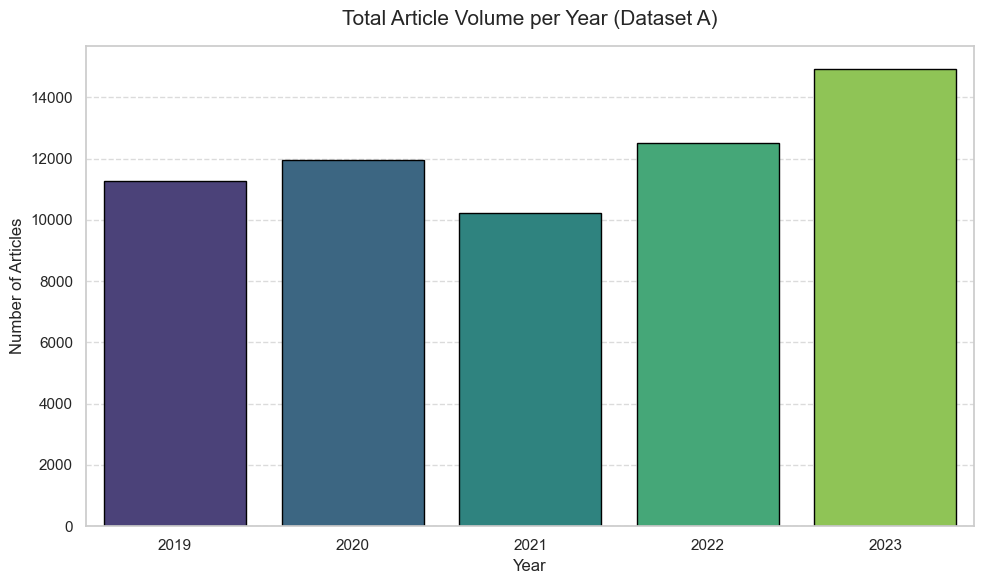

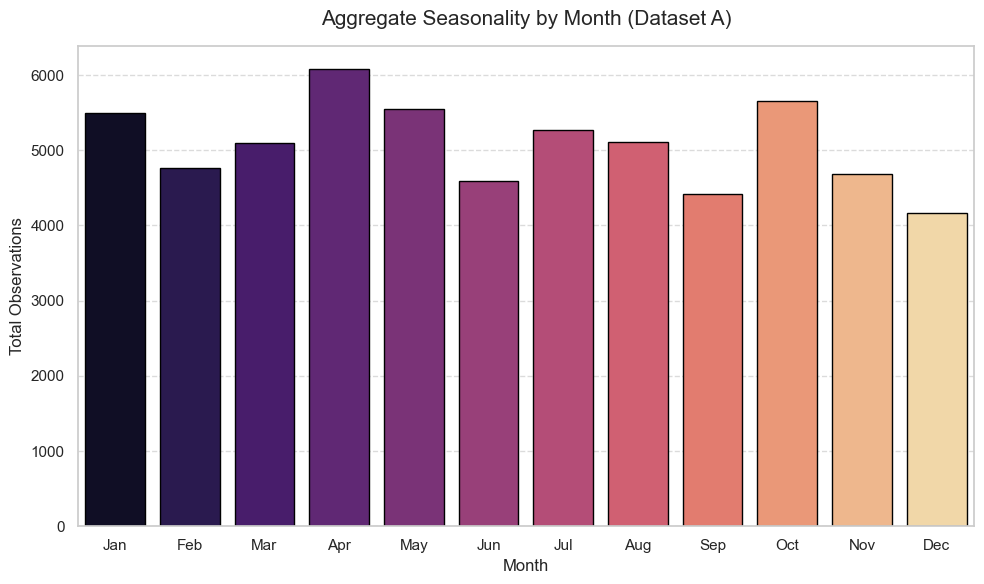

In [49]:
#Articles per month/per year
#Dataset A

def generate_macro_plots(df):
    
    #Date Formatting
    df['Date'] = pd.to_datetime(df['Date'])
    
    #Extracting Year and Month for aggregation
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    
    #Theme
    sns.set_theme(style="whitegrid")
    
    #Chart 1: Articles per Year
    plt.figure(figsize=(10, 6))
    year_counts = df['Year'].value_counts().sort_index()
    
    sns.barplot(
        x=year_counts.index, 
        y=year_counts.values, 
        palette='viridis', 
        edgecolor='black'
    )
    
    plt.title('Total Article Volume per Year (Dataset A)', fontsize=15, pad=15)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Articles', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Dataset A articles_per_year.png', dpi=300)
    plt.show()
    
    
    #Chart 2: Articles per Month
    plt.figure(figsize=(10, 6))
    month_counts = df['Month'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    sns.barplot(
        x=month_names, 
        y=month_counts.values, 
        palette='magma', 
        edgecolor='black'
    )
    
    plt.title('Aggregate Seasonality by Month (Dataset A)', fontsize=15, pad=15)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Total Observations', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Dataset A articles_per_month.png', dpi=300)
    plt.show()



generate_macro_plots(df_cleaned)

A longitudinal analysis of Dataset A reveals a robust temporal coverage spanning [2019] to [2023]. The distribution of article volume per year indicates a stable data acquisition rate, ensuring that the subsequent sentiment models are trained on diverse market conditions including pre- and post-pandemic volatility.This high-density coverage provides the necessary informational depth for the S&P 500 performance forecasting proposed in this study.

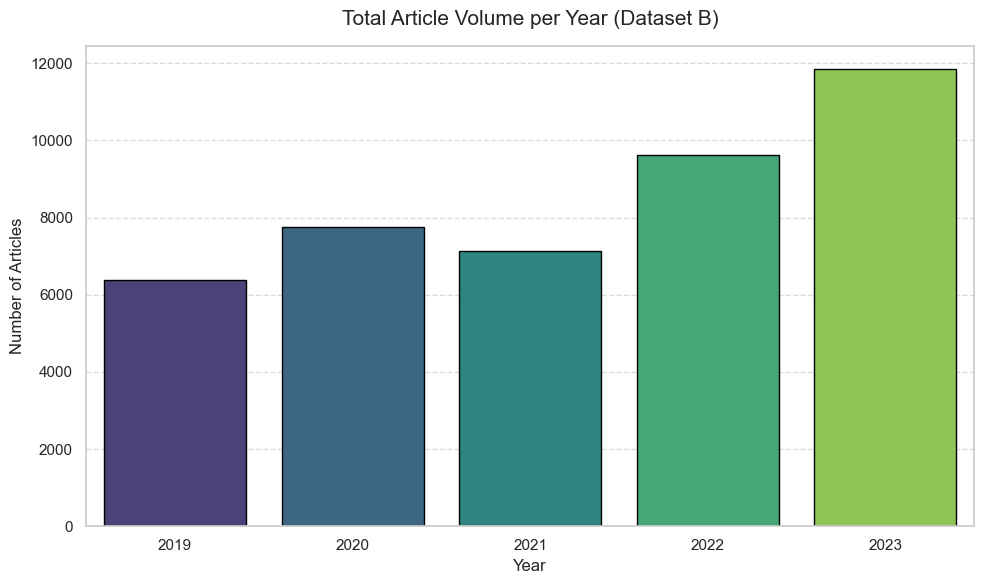

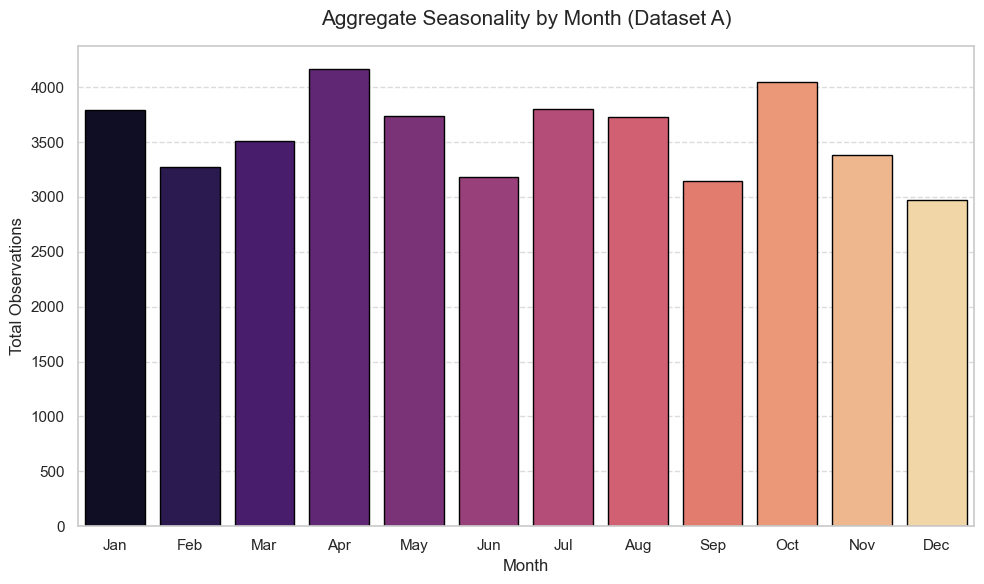

In [50]:
#Articles per month/per year
#Dataset B

def generate_macro_plots(df):
    
    #Date Formatting
    df['Date'] = pd.to_datetime(df['Date'])
    
    #Extracting Year and Month for aggregation
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    
    #Theme
    sns.set_theme(style="whitegrid")
    
    #Chart 1: Articles per Year
    plt.figure(figsize=(10, 6))
    year_counts = df['Year'].value_counts().sort_index()
    
    sns.barplot(
        x=year_counts.index, 
        y=year_counts.values, 
        palette='viridis', 
        edgecolor='black'
    )
    
    plt.title('Total Article Volume per Year (Dataset B)', fontsize=15, pad=15)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Articles', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Dataset B articles_per_year.png', dpi=300)
    plt.show()
    
    
    #Chart 2: Articles per Month
    plt.figure(figsize=(10, 6))
    month_counts = df['Month'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    sns.barplot(
        x=month_names, 
        y=month_counts.values, 
        palette='magma', 
        edgecolor='black'
    )
    
    plt.title('Aggregate Seasonality by Month (Dataset A)', fontsize=15, pad=15)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Total Observations', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Dataset B articles_per_month.png', dpi=300)
    plt.show()


generate_macro_plots(df_final)

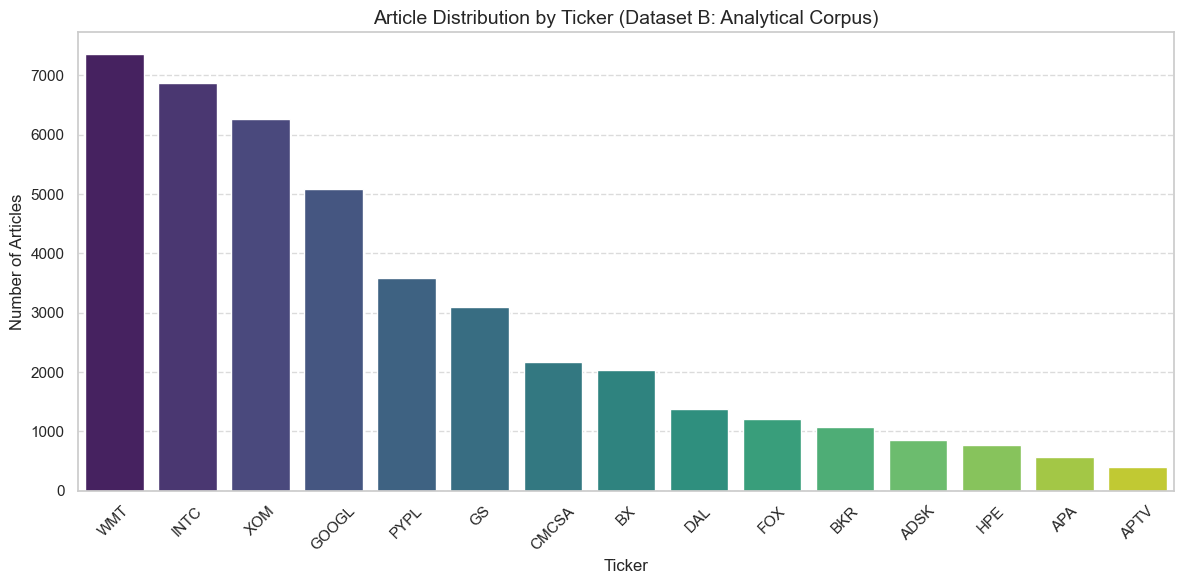

In [51]:
#Dataset B article count distribution by ticker
def plot_ticker_distribution(df):
    plt.figure(figsize=(12, 6))
    ticker_counts = df['Stock_symbol'].value_counts()
    
    sns.barplot(x=ticker_counts.index, y=ticker_counts.values, palette='viridis')
    
    plt.title('Article Distribution by Ticker (Dataset B: Analytical Corpus)', fontsize=14)
    plt.xlabel('Ticker', fontsize=12)
    plt.ylabel('Number of Articles', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('news_count_ticker_distribution.png')
    plt.show() # Uncomment to view locally

plot_ticker_distribution(df_final)

In [52]:
#Data Attrition Table
#Calculated for my 2019-2023 study period
data = {
    "Stage": [
        "FNSPID Data",
        "Study Data", 
        "Post-Duplicates", 
        "Dataset A", #Deere Rows also removed
        "Dataset B" #Transcripts (184 rows removed and relevant news retained)
    ],
    "Count": [92205,65153, 62629, 60903, 42724]
}

df_attrition = pd.DataFrame(data)

#Metrics
df_attrition['Delta_N'] = df_attrition['Count'].diff().fillna(0).astype(int)

#Percentage reduction from previous step
df_attrition['Step_Loss_%'] = (df_attrition['Count'].pct_change() * 100).fillna(0).round(2)

#Cumulative Attrition from the start
start_n = df_attrition['Count'].iloc[0]
df_attrition['Cumulative_Attrition_%'] = ((start_n - df_attrition['Count']) / start_n * 100).round(2)

print("Data Attrition Table")
print(df_attrition)

Data Attrition Table
             Stage  Count  Delta_N  Step_Loss_%  Cumulative_Attrition_%
0      FNSPID Data  92205        0         0.00                    0.00
1       Study Data  65153   -27052       -29.34                   29.34
2  Post-Duplicates  62629    -2524        -3.87                   32.08
3        Dataset A  60903    -1726        -2.76                   33.95
4        Dataset B  42724   -18179       -29.85                   53.66


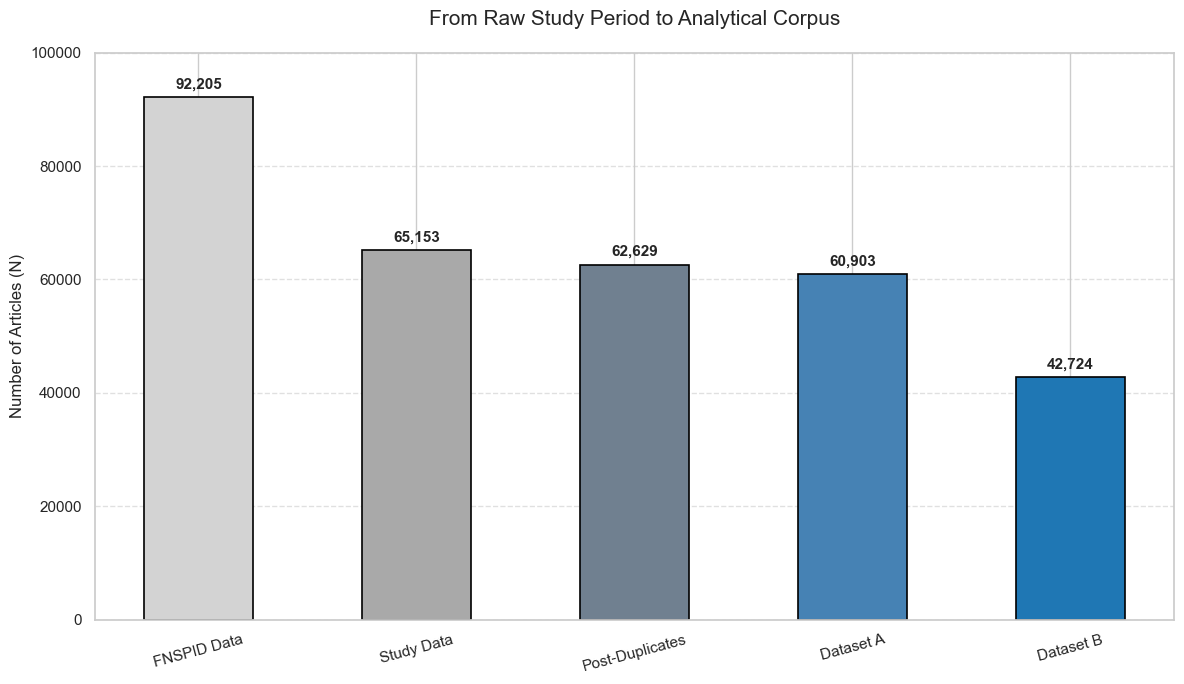

In [53]:
#Attrition Visuals
#Bar Chart
plt.figure(figsize=(12, 7))
# Using an academic gray-to-blue gradient
colors = ['#D3D3D3','#A9A9A9','#708090','#4682B4','#1F77B4'] 

bars = plt.bar(df_attrition['Stage'], df_attrition['Count'], color=colors, edgecolor='black', linewidth=1.2,width=0.5)

# Adding data labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{int(height):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('From Raw Study Period to Analytical Corpus', fontsize=15, pad=20)
plt.ylabel('Number of Articles (N)', fontsize=12)
plt.ylim(0, 100000) # Give room for labels
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('attrition_bar_chart.png', dpi=300)
plt.show()

Data Attrition Pipeline. This figure illustrates the multi-stage filtering process used to refine the dataset. 

In [54]:
#Master Key Table
def generate_ticker_master_key(df):
    #Metrics per ticker
    master_key = df.groupby('Stock_symbol').agg(
    Sample_Size_N=('Article', 'count'),
    Mean_Relevance=('relevance_score', 'mean'),
    Avg_Word_Count=('Article', lambda x: x.apply(lambda y: len(str(y).split())).mean())
    ).reset_index()
    
    #Sector Context for comparative study
    sector_map = {
        'ADSK': 'IT', 'HPE': 'IT', 'INTC': 'IT',
        'PYPL': 'Financials', 'GS': 'Financials', 'BX': 'Financials',
        'DAL': 'Consumer Disc', 'APTV': 'Consumer Disc', 'WMT': 'Consumer Disc',
        'GOOGL': 'Comm Services', 'FOX': 'Comm Services', 'CMCSA': 'Comm Services',
        'XOM': 'Energy', 'BKR': 'Energy', 'APA': 'Energy'
    }
    master_key['Sector'] = master_key['Stock_symbol'].map(sector_map)

    #Formatting(2 decimal places)
    master_key['Mean_Relevance'] = master_key['Mean_Relevance'].round(2)
    master_key['Avg_Word_Count'] = master_key['Avg_Word_Count'].round(0).astype(int)

    #Sorting by Sector then Volume
    master_key = master_key.sort_values(by=['Sample_Size_N'], ascending=[False])
    
    return master_key

#Execution
generate_ticker_master_key(df_final)

,Stock_symbol,Sample_Size_N,Mean_Relevance,Avg_Word_Count,Sector
13,WMT,7356,15.40,809,Consumer Disc
11,INTC,6877,18.45,666,IT
14,XOM,6262,16.08,672,Energy
8,GOOGL,5085,14.59,1017,Comm Services
12,PYPL,3577,20.94,1108,Financials
9,GS,3092,10.47,697,Financials
5,CMCSA,2170,15.09,807,Comm Services
4,BX,2037,15.75,439,Financials
6,DAL,1376,16.02,551,Consumer Disc
7,FOX,1209,18.72,455,Comm Services


The above showcases that even your lowest-frequency ticker has enough articles (e.g., $N > 400$) to allow for a statistically significant test set.

In [55]:
#Exporting final dataset A.
output_dir = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\News'
news_file_path = os.path.join(output_dir, 'News_Dataset B.csv')
df_final.to_csv(news_file_path, index=False)
print(f"Successfully saved!")

Successfully saved!
